# biPCA

## STOmics

In [ ]:
import numpy as np
import scanpy as sc
import torch
from threadpoolctl import threadpool_limits
import bipca
from bipca import plotting

In [ ]:
adata = sc.read_h5ad('./scLENS/scLENS_paper_yh/data/stomics/E16.5_E1S3_cell_bin_whole_brain.h5ad')

In [ ]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=15)
adata

AnnData object with n_obs × n_vars = 65303 × 19182
    obs: 'Slice', 'region', 'sim anno', 'n_genes_by_counts', 'total_counts', 'annotation', 'n_genes'
    var: 'Gene', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'sim anno_colors'
    obsm: 'spatial'
    layers: 'counts'

In [ ]:
raw_X = adata.layers['counts']

In [ ]:
X = raw_X.toarray() if hasattr(raw_X, 'toarray') else np.asarray(raw_X)

In [ ]:
# 18m
n_threads = 16
torch.set_num_threads(n_threads)
with threadpool_limits(limits=n_threads):
    op = bipca.BiPCA(n_components=-1)   # -1 = full SVD (rank 자동 결정)
    Z = op.fit_transform(X)             # biwhitening + shrinkage
    op.get_plotting_spectrum()          # MP-fit 파라미터 계산 (품질 계산)

Calculating BiPCA fit...
  Calculating variance fit over 5 submatrices...


/bce/groups/pnucolab/analysis/stLENS/.bipca/lib/python3.12/site-packages/bipca/math.py:2919: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  rx = np.sqrt(m0b / m0a, where=m0b / m0a > 0)
/bce/groups/pnucolab/analysis/stLENS/.bipca/lib/python3.12/site-packages/bipca/math.py:2921: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  term2 = np.sqrt(m0b * m0a, where=m0b * m0a > 0)


    Chebyshev approximation of KS reached 9.055283831322016e-10 with 65 coefficients
    Estimated b=1.778778932131073, c=0.10757785757956607, KS=0.004602718993708121
    Chebyshev approximation of KS reached 1.7058787897371214e-08 with 65 coefficients
    Estimated b=1.792855900361501, c=0.06912386669199845, KS=0.004174548105370324
    Chebyshev approximation of KS reached 4.806601835661877e-09 with 65 coefficients
    Estimated b=1.7702321381738686, c=0.12563871069283933, KS=0.004300458715596367
    Chebyshev approximation of KS reached 7.471601771489346e-10 with 65 coefficients
    Estimated b=1.777350225433568, c=0.1285294825910673, KS=0.004576659038901587
    Chebyshev approximation of KS reached 6.6144292851911105e-09 with 65 coefficients
    Estimated b=1.7798609696231276, c=0.09113560260524795, KS=0.004606968039159276
    Approximating the mean of all submatrices
    Approximation ratio is 2.1471629350381783e-09 with 65 coefficients
    b=1.7800102328230663, c=0.101950692522502

In [ ]:
op.write_to_adata(adata)  # anndata에 결과 저장

Calculating Writing bipca to anndata...
  Calculating Shrinking singular values according to frobenius loss...
Calculated Writing bipca to anndata in 13.44 seconds.


AnnData object with n_obs × n_vars = 65303 × 19182
    obs: 'Slice', 'region', 'sim anno', 'n_genes_by_counts', 'total_counts', 'annotation', 'n_genes'
    var: 'Gene', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'sim anno_colors', 'bipca'
    obsm: 'spatial', 'U_biwhite'
    varm: 'V_biwhite'
    layers: 'counts', 'Y_biwhite', 'Z_biwhite'

In [ ]:
optimal_pc = adata.uns['bipca']['rank']
print('optimal PC count (biPCA rank):', optimal_pc)

optimal PC count (biPCA rank): 195


In [ ]:
adata.obsm['X_pca']

array([[ -6.8728147 ,  -7.5315113 ,   3.5766761 , ...,   1.2943274 ,
         -0.0201663 ,   1.2438459 ],
       [ -2.4443874 ,  -7.0361366 ,   2.8006275 , ...,  -1.6609912 ,
         -1.2852459 ,  -0.23283987],
       [  2.1763608 ,  -7.385875  ,   4.355783  , ...,  -2.3365836 ,
         -1.0647699 ,   1.4415239 ],
       ...,
       [-11.182491  ,  -5.670398  ,  -5.2266526 , ...,  -0.6539966 ,
         -0.1371806 ,   0.18652193],
       [  0.9403606 ,  -4.3680406 ,  -0.85495   , ...,  -1.7239364 ,
          0.23723315,  -0.96935534],
       [-11.8206415 ,  -7.750383  ,   1.6350827 , ...,   0.89507526,
         -1.3324903 ,   0.96943206]], shape=(65303, 195), dtype=float32)

In [ ]:
sc.pp.neighbors(adata, n_pcs=optimal_pc)
sc.tl.umap(adata)

In [ ]:
# Leiden Clustering across resolutions
def leiden_loop(adata):
    res_range=np.arange(0.5, 5.1, 0.5)
    for res in res_range:
        leiden_key = f"leiden_{res:.1f}"
        if leiden_key not in adata.obs:
            sc.tl.leiden(adata, resolution=res, key_added=leiden_key)

In [ ]:
leiden_loop(adata)

/tmp/ipykernel_3832623/4059026669.py:7: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=res, key_added=leiden_key)


In [ ]:
from sklearn.metrics import jaccard_score
import pandas as pd
from tqdm import tqdm

def optimize_resolution_for_all_celltypes_jaccard(
    adata,
    average,
    annotation_key='annotation',
    res_range=np.arange(0.5, 5.1, 0.5)
):
    summary = []
    cell_types = adata.obs[annotation_key].cat.categories

    for cell_type in tqdm(cell_types, desc="Processing cell types"):
        jaccard_scores = []
        best_clusters = []
        resolutions_checked = []

        gt_mask = adata.obs[annotation_key] == cell_type
        if gt_mask.sum() == 0:
            continue

        for res in res_range:
            leiden_key = f"leiden_{res:.1f}"
            if leiden_key not in adata.obs.columns:
                continue
            
            cluster_names = adata.obs[leiden_key].cat.categories
            best_jaccard = -1
            best_cluster = None

            for cluster in cluster_names:
                pred_mask = adata.obs[leiden_key] == cluster

                _, score = jaccard_score(gt_mask, pred_mask, average=average)
                if score > best_jaccard:
                    best_jaccard = score
                    best_cluster = cluster

            jaccard_scores.append(best_jaccard)
            best_clusters.append(best_cluster)
            resolutions_checked.append(res)

        df = pd.DataFrame({
            'resolution': resolutions_checked,
            'jaccard': jaccard_scores,
            'best_cluster': best_clusters
        })

        best_idx = df['jaccard'].idxmax()
        best_row = df.loc[best_idx]
        summary.append({
            'cell_type': cell_type,
            'best_resolution': best_row['resolution'],
            'best_cluster': best_row['best_cluster'],
            'best_jaccard': best_row['jaccard']
        })

    return pd.DataFrame(summary)


In [ ]:
summary_df_stlens_st = pd.read_csv('./scLENS/output/stomics/summary_df_stlens.csv')

In [ ]:
stlens_adata_st = sc.read_h5ad('./scLENS/output/stomics/stlens_result.h5ad')

In [ ]:
name_map = {
    'Cajal-Retzius cell': 'Cajal',
    'Cerebellar granule neuroblasts': 'Cerebellar GN',
    'Choroid plexus': 'Choroid',
    'Cortical glutamatergic neuron': 'Ctx Glu neuron',
    'Cortical intermediate progenitor': 'Ctx IP',
    'Cortical or hippocampal glutamatergic neuron': 'Ctx/Hip Glu neuron',
    'Cranium fibroblast': 'Cranium FB',
    'Diencephalon glutamatergic neuron': 'Dience Glu neuron',
    'Dopaminergic neuron': 'DA neuron',
    'Dorsal hindbrain radial glia': 'Dorsal HB RG',
    'Endothelial cell': 'Endo',
    'Epidermis': 'Epid',
    'Erythrocyte': 'RBC',
    'Fibroblast': 'FB',
    'Forebrain GABAergic neuroblast': 'FB GABA NB',
    'Forebrain GABAergic neuron': 'FB GABA neuron',
    'Forebrain glutamatergic neuroblast': 'FB Glu NB',
    'Forebrain neuroblast': 'FB NB',
    'Forebrain radial glia': 'FB RG',
    'Hindbrain glioblast': 'HB GB',
    'Hindbrain glutamatergic neuroblast': 'HB Glu NB',
    'Hindbrain glutamatergic neuron': 'HB Glu neuron',
    'Hindbrain neuroblast': 'HB NB',
    'Hypothalamus neuron': 'Hypo neuron',
    'Midbrain glutamatergic neuroblast': 'MB Glu NB',
    'Midbrain glutamatergic neuron': 'MB Glu neuron',
    'Midbrain radial glia': 'MB RG',
    'Mixed region GABAergic neuron': 'Mixed GABA neuron',
    'Mixed region glioblast': 'Mixed GB',
    'Mixed region neuron': 'Mixed neuron',
    'Motor neuron': 'Motor neuron',
    'Olfactory neuron': 'Olf neuron',
    'Ventromedial hypothalamus GABAergic neuron': 'VMH GABA neuron'
}

In [ ]:
adata.obs['Chen et al.'] = adata.obs['annotation'].cat.rename_categories(name_map)

In [ ]:
summary_df_bipca_st = optimize_resolution_for_all_celltypes_jaccard(
    adata, 
    annotation_key = 'Chen et al.', 
    average = None)

Processing cell types: 100%|██████████| 34/34 [07:52<00:00, 13.91s/it]


In [ ]:
adata.write_h5ad('./stLENS/dataset/paper/PCA_method/bipca_adata.h5ad')

In [ ]:
summary_df_bipca_st.to_csv('./stLENS/dataset/paper/PCA_method/summary_df_bipca.csv', )

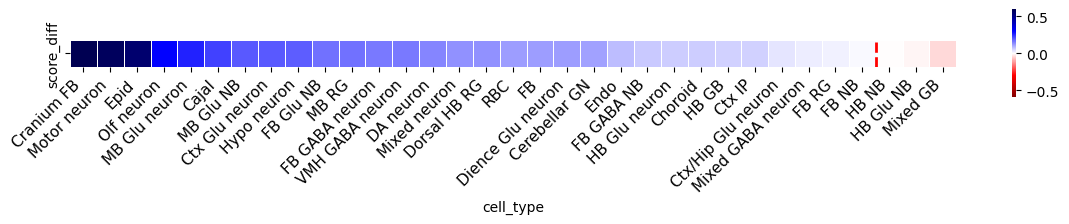

In [ ]:
# Leiden measures - heatmap

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


merged_st = pd.merge(
    summary_df_stlens_st,
    summary_df_bipca_st,
    on='cell_type',
    suffixes=('_stlens', '_bipca')
    )

# Calculate correlation difference
merged_st['score_diff'] = merged_st['best_jaccard_stlens'] - merged_st['best_jaccard_bipca']

# Sort by score difference
merged_st = merged_st.sort_values(by='score_diff', ascending=False).reset_index(drop=True)

# Prepare data for heatmap
heatmap_data = merged_st[['cell_type', 'score_diff']].set_index('cell_type').T

# Plot heatmap
plt.figure(figsize=(12, 2))

ax = sns.heatmap(
    heatmap_data,
    cmap='seismic_r',
    center=0,
    vmin=-0.6,
    vmax=0.6,
    annot=False,
    fmt='.2f',
    linewidths=0.5
    )

cell_labels = heatmap_data.columns

ax.set_xticks(np.arange(len(cell_labels)) + 0.5)

ax.set_xticklabels(cell_labels, rotation=45, ha='right', fontsize=11)

ax.set_aspect(aspect=1)

# red line
corrs = list(merged_st['score_diff'])

for i in range(len(corrs)-1):
    if corrs[i] * corrs[i+1] < 0:
        plt.axvline(x=i+1, color='red', linestyle='--', linewidth=2)
        break
plt.tight_layout()
plt.savefig('./stLENS/dataset/paper/PCA_method/bipca_heatmap_stomics.pdf', dpi=300)
plt.show()

## visiumHD

In [ ]:
import numpy as np
import scanpy as sc
import torch
from threadpoolctl import threadpool_limits
import bipca
from bipca import plotting

In [ ]:
adata = sc.read_h5ad('./scLENS/scLENS_paper_yh/data/visiumhd/anndata_human_crc.h5ad')

/bce/groups/pnucolab/analysis/stLENS/.bipca/lib/python3.12/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [ ]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=15)
adata

AnnData object with n_obs × n_vars = 159526 × 16798
    obs: 'in_tissue', 'array_row', 'array_col', 'location_id', 'region', 'DeconvolutionClass', 'DeconvolutionLabel1', 'DeconvolutionLabel2', 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'

In [ ]:
raw_X = adata.X

In [ ]:
X = raw_X.toarray() if hasattr(raw_X, 'toarray') else np.asarray(raw_X)

In [ ]:
n_threads = 16
torch.set_num_threads(n_threads)
with threadpool_limits(limits=n_threads):
    op = bipca.BiPCA(n_components=-1)   # -1 = full SVD (rank 자동 결정)
    Z = op.fit_transform(X)             # biwhitening + shrinkage
    op.get_plotting_spectrum()          # MP-fit 파라미터 계산 (품질 계산)

Calculating BiPCA fit...


  Calculating variance fit over 5 submatrices...


/bce/groups/pnucolab/analysis/stLENS/.bipca/lib/python3.12/site-packages/bipca/math.py:2919: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  rx = np.sqrt(m0b / m0a, where=m0b / m0a > 0)
/bce/groups/pnucolab/analysis/stLENS/.bipca/lib/python3.12/site-packages/bipca/math.py:2921: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  term2 = np.sqrt(m0b * m0a, where=m0b * m0a > 0)


    Chebyshev approximation of KS reached 8.178153302319634e-09 with 65 coefficients


    Estimated b=1.0506385494075883, c=0.0, KS=0.006199757726537136


...

Calculating Shrinking singular values according to frobenius loss...


Calculating plotting spectra...


  Calculating spectrum of biwhitened data...


  Calculated spectrum of biwhitened data in 0.04 seconds.


Calculated plotting spectra in 0.04 seconds.


In [ ]:
op.write_to_adata(adata) 

Calculating Writing bipca to anndata...


  Calculating Shrinking singular values according to frobenius loss...


Calculated Writing bipca to anndata in 47.03 seconds.


AnnData object with n_obs × n_vars = 159526 × 16798
    obs: 'in_tissue', 'array_row', 'array_col', 'location_id', 'region', 'DeconvolutionClass', 'DeconvolutionLabel1', 'DeconvolutionLabel2', 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'spatialdata_attrs', 'bipca'
    obsm: 'spatial', 'U_biwhite'
    varm: 'V_biwhite'
    layers: 'Y_biwhite', 'Z_biwhite'

In [ ]:
optimal_pc = adata.uns['bipca']['rank']
print('optimal PC count (biPCA rank):', optimal_pc)

optimal PC count (biPCA rank): 112


In [ ]:
sc.pp.neighbors(adata, n_pcs=optimal_pc)
sc.tl.umap(adata)

/tmp/ipykernel_341469/1733117356.py:1: UserWarning: You’re trying to run this on 16798 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  sc.pp.neighbors(adata, n_pcs=optimal_pc)


/bce/groups/pnucolab/analysis/stLENS/.bipca/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Leiden Clustering across resolutions
def leiden_loop(adata):
    res_range=np.arange(0.5, 5.1, 0.5)
    for res in res_range:
        leiden_key = f"leiden_{res:.1f}"
        if leiden_key not in adata.obs:
            sc.tl.leiden(adata, resolution=res, key_added=leiden_key)

In [ ]:
leiden_loop(adata)

/tmp/ipykernel_341469/2986899218.py:7: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=res, key_added=leiden_key)


In [ ]:
from sklearn.metrics import jaccard_score
import pandas as pd
from tqdm import tqdm

def optimize_resolution_for_all_celltypes_jaccard(
    adata,
    average,
    annotation_key='annotation',
    res_range=np.arange(0.5, 5.1, 0.5)
):
    summary = []
    cell_types = adata.obs[annotation_key].cat.categories

    for cell_type in tqdm(cell_types, desc="Processing cell types"):
        jaccard_scores = []
        best_clusters = []
        resolutions_checked = []

        gt_mask = adata.obs[annotation_key] == cell_type
        if gt_mask.sum() == 0:
            continue

        for res in res_range:
            leiden_key = f"leiden_{res:.1f}"
            if leiden_key not in adata.obs.columns:
                continue
            
            cluster_names = adata.obs[leiden_key].cat.categories
            best_jaccard = -1
            best_cluster = None

            for cluster in cluster_names:
                pred_mask = adata.obs[leiden_key] == cluster

                _, score = jaccard_score(gt_mask, pred_mask, average=average)
                if score > best_jaccard:
                    best_jaccard = score
                    best_cluster = cluster

            jaccard_scores.append(best_jaccard)
            best_clusters.append(best_cluster)
            resolutions_checked.append(res)

        df = pd.DataFrame({
            'resolution': resolutions_checked,
            'jaccard': jaccard_scores,
            'best_cluster': best_clusters
        })

        best_idx = df['jaccard'].idxmax()
        best_row = df.loc[best_idx]
        summary.append({
            'cell_type': cell_type,
            'best_resolution': best_row['resolution'],
            'best_cluster': best_row['best_cluster'],
            'best_jaccard': best_row['jaccard']
        })

    return pd.DataFrame(summary)


In [ ]:
summary_df_stlens_vi = pd.read_csv('./scLENS/output/visiumhd/summary_df_stlens.csv')

In [ ]:
stlens_adata_vi = sc.read_h5ad('./scLENS/output/visiumhd/stlens_result.h5ad')

/bce/groups/pnucolab/analysis/stLENS/.bipca/lib/python3.12/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [ ]:
name_map = {
    'Goblet': 'Goblet',
    'Tumor II': 'Tumor2',
    'CD4 T cell': 'CD4 T',
    'CAF': 'CAF',
    'Macrophage': 'Macro',
    'Proliferating Fibroblast': 'ProFib',
    'Tumor III': 'Tumor3',
    'Mature B': 'B Mature',
    'Pericytes': 'Pericyte',
    'Myofibroblast': 'MyoFib',
    'Endothelial': 'Endo',
    'CD8 T cell': 'CD8 T',
    'Tuft': 'Tuft',
    'Proliferating Macrophages': 'ProMacro',
    'Enterocyte': 'Entero',
    'Fibroblast': 'Fibro',
    'cDC I': 'cDC1',
    'mRegDC': 'mRegDC',
    'Plasma': 'Plasma',
    'Enteric Glial': 'Glial',
    'Tumor V': 'Tumor5',
    'Proliferating Immune II': 'ProImmune2',
    'Neutrophil': 'Neutro',
    'Tumor IV': 'Tumor4',
    'Neuroendocrine': 'Neuroendo',
    'Lymphatic Endothelial': 'LymphEndo',
    'Mast': 'Mast',
    'pDC': 'pDC',
    'Tumor I': 'Tumor1',
    'Epithelial': 'Epi',
    'vSM': 'vSM',
    'Smooth Muscle': 'SM',
    'Memory B': 'B Memory',
    'Adipocyte': 'Adipo',
    'SM Stress Response': 'SM_Stress',
    'NK': 'NK'
    }

In [ ]:
adata.obs['Faria de Oliveira et al.'] = adata.obs['DeconvolutionLabel1'].cat.rename_categories(name_map)

In [ ]:
summary_df_bipca_st = optimize_resolution_for_all_celltypes_jaccard(
    adata, 
    annotation_key = 'Faria de Oliveira et al.', 
    average = None)


Processing cell types:   0%|          | 0/37 [00:00<?, ?it/s]


Processing cell types:   3%|▎         | 1/37 [00:19<11:30, 19.19s/it]


Processing cell types:   5%|▌         | 2/37 [00:38<11:23, 19.52s/it]


Processing cell types:   8%|▊         | 3/37 [00:58<11:03, 19.52s/it]


Processing cell types:  11%|█         | 4/37 [01:17<10:41, 19.44s/it]

...


Processing cell types:  92%|█████████▏| 34/37 [11:01<00:57, 19.28s/it]


Processing cell types:  95%|█████████▍| 35/37 [11:20<00:38, 19.24s/it]


Processing cell types:  97%|█████████▋| 36/37 [11:39<00:19, 19.23s/it]


Processing cell types: 100%|██████████| 37/37 [11:58<00:00, 19.24s/it]


Processing cell types: 100%|██████████| 37/37 [11:58<00:00, 19.43s/it]

In [ ]:
import anndata
anndata.settings.allow_write_nullable_strings = True

In [ ]:
adata.write_h5ad('./stLENS/dataset/paper/PCA_method/bipca_vi_adata.h5ad')

In [ ]:
summary_df_bipca_vi.to_csv('./scLENS/dataset/paper/PCA_method/summary_df_bipca_vi.csv', )

In [ ]:
import matplotlib as mpl
mpl.rcParams['text.usetex'] = False

In [ ]:
import pandas as pd
summary_df_stlens_vi = pd.read_csv('./scLENS/output/visiumhd/summary_df_stlens.csv', index_col=0)
summary_df_bipca_vi  = pd.read_csv('./scLENS/dataset/paper/PCA_method/summary_df_bipca_vi.csv', index_col=0)

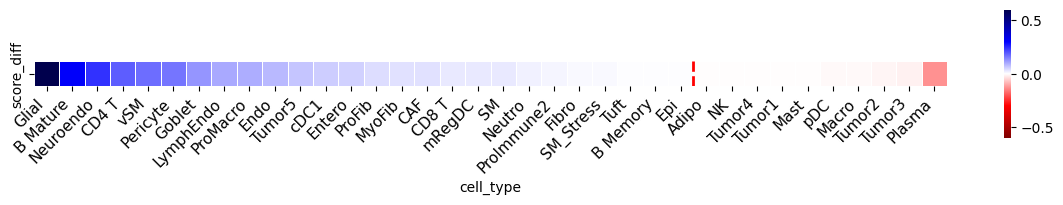

In [ ]:
# Leiden measures - heatmap

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

merged_st = pd.merge(
    summary_df_stlens_vi,
    summary_df_bipca_vi,
    on='cell_type',
    suffixes=('_stlens', '_bipca')
    )

# Calculate correlation difference
merged_st['score_diff'] = merged_st['best_jaccard_stlens'] - merged_st['best_jaccard_bipca']

# Sort by score difference
merged_st = merged_st.sort_values(by='score_diff', ascending=False).reset_index(drop=True)

# Prepare data for heatmap
heatmap_data = merged_st[['cell_type', 'score_diff']].set_index('cell_type').T

# Plot heatmap
plt.figure(figsize=(12, 2))

ax = sns.heatmap(
    heatmap_data,
    cmap='seismic_r',
    center=0,
    vmin=-0.6,
    vmax=0.6,
    annot=False,
    fmt='.2f',
    linewidths=0.5
    )

cell_labels = heatmap_data.columns

ax.set_xticks(np.arange(len(cell_labels)) + 0.5)

ax.set_xticklabels(cell_labels, rotation=45, ha='right', fontsize=11)

ax.set_aspect(aspect=1)

# red line
corrs = list(merged_st['score_diff'])

for i in range(len(corrs)-1):
    if corrs[i] * corrs[i+1] < 0:
        plt.axvline(x=i+1, color='red', linestyle='--', linewidth=2)
        break
plt.tight_layout()
plt.savefig('./stLENS/dataset/paper/PCA_method/bipca_heatmap_visium.pdf', dpi=300)
plt.show()

# kneed

## STOmics

In [ ]:
import scanpy as sc
adata_knst = sc.read_h5ad('./scLENS/scLENS_paper_yh/data/stomics/E16.5_E1S3_cell_bin_whole_brain.h5ad')
adata_knst

AnnData object with n_obs × n_vars = 65303 × 23368
    obs: 'Slice', 'region', 'sim anno', 'n_genes_by_counts', 'total_counts', 'annotation'
    var: 'Gene', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'total_counts', 'log1p_total_counts'
    uns: 'sim anno_colors'
    obsm: 'spatial'
    layers: 'counts'

In [ ]:
import matplotlib.pyplot as plt
from kneed import KneeLocator, find_shape

In [ ]:
sc.pp.filter_cells(adata_knst, min_genes=200)
sc.pp.filter_genes(adata_knst, min_cells=15)
adata_knst

AnnData object with n_obs × n_vars = 65303 × 19182
    obs: 'Slice', 'region', 'sim anno', 'n_genes_by_counts', 'total_counts', 'annotation', 'n_genes'
    var: 'Gene', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'sim anno_colors'
    obsm: 'spatial'
    layers: 'counts'

In [ ]:
sc.pp.normalize_total(adata_knst)
sc.pp.log1p(adata_knst)
sc.pp.pca(adata_knst, n_comps=100)

In [ ]:
import numpy as np

y = adata_knst.uns['pca']['variance_ratio']
x = np.arange(1, len(y) + 1)

8


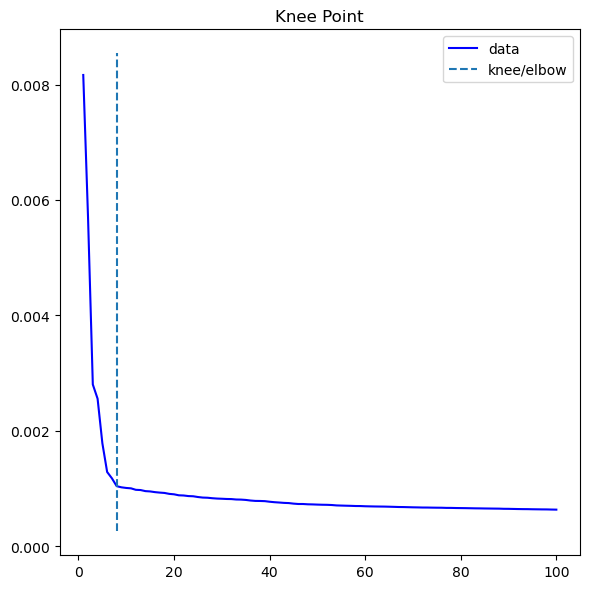

In [ ]:
direction, curve = find_shape(x, y)
kl = KneeLocator(x, y, curve=curve, direction=direction)
optimal_pc = int(kl.knee)  

print(kl.knee)
kl.plot_knee()

plt.tight_layout()
plt.savefig('./stLENS/dataset/paper/stomics/stomics_knee_plot.pdf', dpi=300, bbox_inches='tight')   # 경로는 필요에 맞게 조정
plt.show()

In [ ]:
sc.pp.neighbors(adata_knst, n_pcs=optimal_pc)
sc.tl.umap(adata_knst)

/home/khyeonmin/micromamba/envs/stLENS/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
def leiden_loop(adata):
    res_range=np.arange(0.5, 5.1, 0.5)

    for res in res_range:
        leiden_key = f"leiden_{res:.1f}"
        if leiden_key not in adata.obs:
            sc.tl.leiden(adata, resolution=res, key_added=leiden_key)

leiden_loop(adata_knst)
adata_knst

AnnData object with n_obs × n_vars = 64718 × 19182
    obs: 'Slice', 'region', 'sim anno', 'n_genes_by_counts', 'total_counts', 'annotation', 'n_genes', 'leiden_0.5', 'leiden_1.0', 'leiden_1.5', 'leiden_2.0', 'leiden_2.5', 'leiden_3.0', 'leiden_3.5', 'leiden_4.0', 'leiden_4.5', 'leiden_5.0'
    var: 'Gene', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'sim anno_colors', 'log1p', 'pca', 'neighbors', 'umap', 'leiden_0.5', 'leiden_1.0', 'leiden_1.5', 'leiden_2.0', 'leiden_2.5', 'leiden_3.0', 'leiden_3.5', 'leiden_4.0', 'leiden_4.5', 'leiden_5.0'
    obsm: 'spatial', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [ ]:
adata_knst.write_h5ad('./stLENS/dataset/paper/stomics/kneed.h5ad')

In [ ]:
from sklearn.metrics import jaccard_score
import numpy as np
import pandas as pd
from tqdm import tqdm

def optimize_resolution_for_all_celltypes_jaccard(
    adata,
    average,
    annotation_key='annotation',
    res_range=np.arange(0.5, 5.1, 0.5)
):
    summary = []
    cell_types = adata.obs[annotation_key].cat.categories

    for cell_type in tqdm(cell_types, desc="Processing cell types"):
        jaccard_scores = []
        best_clusters = []
        resolutions_checked = []

        gt_mask = adata.obs[annotation_key] == cell_type
        if gt_mask.sum() == 0:
            continue

        for res in res_range:
            leiden_key = f"leiden_{res:.1f}"
            if leiden_key not in adata.obs.columns:
                continue
            
            cluster_names = adata.obs[leiden_key].cat.categories
            best_jaccard = -1
            best_cluster = None

            for cluster in cluster_names:
                pred_mask = adata.obs[leiden_key] == cluster

                _, score = jaccard_score(gt_mask, pred_mask, average=average)
                if score > best_jaccard:
                    best_jaccard = score
                    best_cluster = cluster

            jaccard_scores.append(best_jaccard)
            best_clusters.append(best_cluster)
            resolutions_checked.append(res)

        df = pd.DataFrame({
            'resolution': resolutions_checked,
            'jaccard': jaccard_scores,
            'best_cluster': best_clusters
        })

        best_idx = df['jaccard'].idxmax()
        best_row = df.loc[best_idx]
        summary.append({
            'cell_type': cell_type,
            'best_resolution': best_row['resolution'],
            'best_cluster': best_row['best_cluster'],
            'best_jaccard': best_row['jaccard']
        })

    return pd.DataFrame(summary)


In [ ]:
import pandas as pd
summary_df_stlens_st = pd.read_csv('./scLENS/output/stomics/summary_df_stlens.csv')

In [ ]:
stlens_adata_st = sc.read_h5ad('./scLENS/output/stomics/stlens_result.h5ad')

In [ ]:
name_map = {
    'Cajal-Retzius cell': 'Cajal',
    'Cerebellar granule neuroblasts': 'Cerebellar GN',
    'Choroid plexus': 'Choroid',
    'Cortical glutamatergic neuron': 'Ctx Glu neuron',
    'Cortical intermediate progenitor': 'Ctx IP',
    'Cortical or hippocampal glutamatergic neuron': 'Ctx/Hip Glu neuron',
    'Cranium fibroblast': 'Cranium FB',
    'Diencephalon glutamatergic neuron': 'Dience Glu neuron',
    'Dopaminergic neuron': 'DA neuron',
    'Dorsal hindbrain radial glia': 'Dorsal HB RG',
    'Endothelial cell': 'Endo',
    'Epidermis': 'Epid',
    'Erythrocyte': 'RBC',
    'Fibroblast': 'FB',
    'Forebrain GABAergic neuroblast': 'FB GABA NB',
    'Forebrain GABAergic neuron': 'FB GABA neuron',
    'Forebrain glutamatergic neuroblast': 'FB Glu NB',
    'Forebrain neuroblast': 'FB NB',
    'Forebrain radial glia': 'FB RG',
    'Hindbrain glioblast': 'HB GB',
    'Hindbrain glutamatergic neuroblast': 'HB Glu NB',
    'Hindbrain glutamatergic neuron': 'HB Glu neuron',
    'Hindbrain neuroblast': 'HB NB',
    'Hypothalamus neuron': 'Hypo neuron',
    'Midbrain glutamatergic neuroblast': 'MB Glu NB',
    'Midbrain glutamatergic neuron': 'MB Glu neuron',
    'Midbrain radial glia': 'MB RG',
    'Mixed region GABAergic neuron': 'Mixed GABA neuron',
    'Mixed region glioblast': 'Mixed GB',
    'Mixed region neuron': 'Mixed neuron',
    'Motor neuron': 'Motor neuron',
    'Olfactory neuron': 'Olf neuron',
    'Ventromedial hypothalamus GABAergic neuron': 'VMH GABA neuron'
}

adata_knst.obs['Chen et al.'] = adata_knst.obs['annotation'].replace(name_map)

/tmp/ipykernel_361176/3088904764.py:37: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_knst.obs['Chen et al.'] = adata_knst.obs['annotation'].replace(name_map)


In [ ]:
adata_knst

AnnData object with n_obs × n_vars = 64718 × 19182
    obs: 'Slice', 'region', 'sim anno', 'n_genes_by_counts', 'total_counts', 'annotation', 'n_genes', 'leiden_0.5', 'leiden_1.0', 'leiden_1.5', 'leiden_2.0', 'leiden_2.5', 'leiden_3.0', 'leiden_3.5', 'leiden_4.0', 'leiden_4.5', 'leiden_5.0', 'Chen et al.'
    var: 'Gene', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'sim anno_colors', 'log1p', 'pca', 'neighbors', 'umap', 'leiden_0.5', 'leiden_1.0', 'leiden_1.5', 'leiden_2.0', 'leiden_2.5', 'leiden_3.0', 'leiden_3.5', 'leiden_4.0', 'leiden_4.5', 'leiden_5.0'
    obsm: 'spatial', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [ ]:
summary_df_kneed_st = optimize_resolution_for_all_celltypes_jaccard(
    adata_knst, 
    annotation_key = 'Chen et al.', 
    average = None)

Processing cell types: 100%|██████████| 33/33 [08:07<00:00, 14.78s/it]


In [ ]:
summary_df_kneed_st.to_csv('./stLENS/dataset/paper/stomics/summary_df_kneed.csv', )

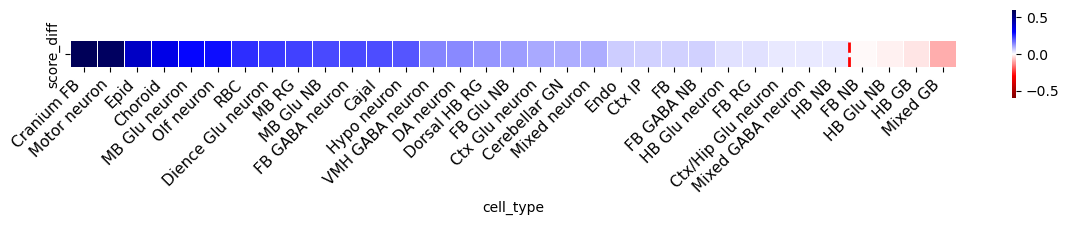

In [ ]:
# Leiden measures - heatmap

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


merged_st = pd.merge(
    summary_df_stlens_st,
    summary_df_kneed_st,
    on='cell_type',
    suffixes=('_stlens', '_kneed')
    )

# Calculate correlation difference
merged_st['score_diff'] = merged_st['best_jaccard_stlens'] - merged_st['best_jaccard_kneed']

# Sort by score difference
merged_st = merged_st.sort_values(by='score_diff', ascending=False).reset_index(drop=True)

# Prepare data for heatmap
heatmap_data = merged_st[['cell_type', 'score_diff']].set_index('cell_type').T

# Plot heatmap
plt.figure(figsize=(12, 2))

ax = sns.heatmap(
    heatmap_data,
    cmap='seismic_r',
    center=0,
    vmin=-0.6,
    vmax=0.6,
    annot=False,
    fmt='.2f',
    linewidths=0.5
    )

cell_labels = heatmap_data.columns

ax.set_xticks(np.arange(len(cell_labels)) + 0.5)

ax.set_xticklabels(cell_labels, rotation=45, ha='right', fontsize=11)

ax.set_aspect(aspect=1)

# red line
corrs = list(merged_st['score_diff'])

for i in range(len(corrs)-1):
    if corrs[i] * corrs[i+1] < 0:
        plt.axvline(x=i+1, color='red', linestyle='--', linewidth=2)
        break
plt.tight_layout()
plt.savefig('./stLENS/output/kneed_heatmap_stomics.pdf', dpi=300)
plt.show()

## VisiumHD

In [ ]:
import scanpy as sc
adata_kn = sc.read_h5ad('./scLENS/scLENS_paper_yh/data/visiumhd/anndata_human_crc.h5ad')
adata_kn

/home/khyeonmin/micromamba/envs/stLENS/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 311355 × 18085
    obs: 'in_tissue', 'array_row', 'array_col', 'location_id', 'region', 'DeconvolutionClass', 'DeconvolutionLabel1', 'DeconvolutionLabel2'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'

In [ ]:
import matplotlib.pyplot as plt
from kneed import KneeLocator, find_shape

In [ ]:
sc.pp.filter_cells(adata_kn, min_genes=200)
sc.pp.filter_genes(adata_kn, min_cells=15)
adata_kn

/home/khyeonmin/micromamba/envs/stLENS/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/khyeonmin/micromamba/envs/stLENS/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 159526 × 16798
    obs: 'in_tissue', 'array_row', 'array_col', 'location_id', 'region', 'DeconvolutionClass', 'DeconvolutionLabel1', 'DeconvolutionLabel2', 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'

In [ ]:
sc.pp.normalize_total(adata_kn)
sc.pp.log1p(adata_kn)
sc.pp.pca(adata_kn, n_comps=100)

In [ ]:
import numpy as np

y = adata_kn.uns['pca']['variance_ratio']
x = np.arange(1, len(y) + 1)

5


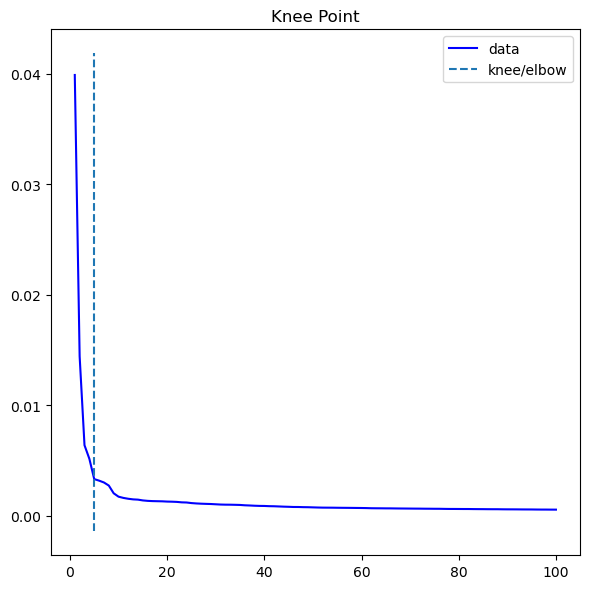

In [ ]:
direction, curve = find_shape(x, y)
kl = KneeLocator(x, y, curve=curve, direction=direction)
optimal_pc = int(kl.knee)

print(kl.knee)

kl.plot_knee()
plt.tight_layout()
plt.savefig('./stLENS/dataset/paper/visiumhd/visium_knee_plot.pdf', dpi=300, bbox_inches='tight')   # 경로는 필요에 맞게 조정
plt.show()

In [ ]:
sc.pp.neighbors(adata_kn, n_pcs=optimal_pc)
sc.tl.umap(adata_kn)

/home/khyeonmin/micromamba/envs/stLENS/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
def leiden_loop(adata):
    res_range=np.arange(0.5, 5.1, 0.5)

    for res in res_range:
        leiden_key = f"leiden_{res:.1f}"
        if leiden_key not in adata.obs:
            sc.tl.leiden(adata, resolution=res, key_added=leiden_key)

leiden_loop(adata_kn)
adata_kn

/tmp/ipykernel_361176/1002664172.py:8: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=res, key_added=leiden_key)


AnnData object with n_obs × n_vars = 159488 × 16798
    obs: 'in_tissue', 'array_row', 'array_col', 'location_id', 'region', 'DeconvolutionClass', 'DeconvolutionLabel1', 'DeconvolutionLabel2', 'n_genes', 'leiden_0.5', 'leiden_1.0', 'leiden_1.5', 'leiden_2.0', 'leiden_2.5', 'leiden_3.0', 'leiden_3.5', 'leiden_4.0', 'leiden_4.5', 'leiden_5.0'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'spatialdata_attrs', 'log1p', 'pca', 'neighbors', 'umap', 'leiden_0.5', 'leiden_1.0', 'leiden_1.5', 'leiden_2.0', 'leiden_2.5', 'leiden_3.0', 'leiden_3.5', 'leiden_4.0', 'leiden_4.5', 'leiden_5.0'
    obsm: 'spatial', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [ ]:
from sklearn.metrics import jaccard_score
import numpy as np
import pandas as pd
from tqdm import tqdm

def optimize_resolution_for_all_celltypes_jaccard(
    adata,
    average,
    annotation_key='annotation',
    res_range=np.arange(0.5, 5.1, 0.5)
):
    summary = []
    cell_types = adata.obs[annotation_key].cat.categories

    for cell_type in tqdm(cell_types, desc="Processing cell types"):
        jaccard_scores = []
        best_clusters = []
        resolutions_checked = []

        gt_mask = adata.obs[annotation_key] == cell_type
        if gt_mask.sum() == 0:
            continue

        for res in res_range:
            leiden_key = f"leiden_{res:.1f}"
            if leiden_key not in adata.obs.columns:
                continue
            
            cluster_names = adata.obs[leiden_key].cat.categories
            best_jaccard = -1
            best_cluster = None

            for cluster in cluster_names:
                pred_mask = adata.obs[leiden_key] == cluster

                _, score = jaccard_score(gt_mask, pred_mask, average=average)
                if score > best_jaccard:
                    best_jaccard = score
                    best_cluster = cluster

            jaccard_scores.append(best_jaccard)
            best_clusters.append(best_cluster)
            resolutions_checked.append(res)

        df = pd.DataFrame({
            'resolution': resolutions_checked,
            'jaccard': jaccard_scores,
            'best_cluster': best_clusters
        })

        best_idx = df['jaccard'].idxmax()
        best_row = df.loc[best_idx]
        summary.append({
            'cell_type': cell_type,
            'best_resolution': best_row['resolution'],
            'best_cluster': best_row['best_cluster'],
            'best_jaccard': best_row['jaccard']
        })

    return pd.DataFrame(summary)


In [ ]:
import pandas as pd
summary_df_stlens = pd.read_csv('./scLENS/output/visiumhd/summary_df_stlens.csv')

In [ ]:
stlens_adata = sc.read_h5ad('./scLENS/output/visiumhd/stlens_result.h5ad')

/home/khyeonmin/micromamba/envs/stLENS/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [ ]:
name_map = {
    'Goblet': 'Goblet',
    'Tumor II': 'Tumor2',
    'CD4 T cell': 'CD4 T',
    'CAF': 'CAF',
    'Macrophage': 'Macro',
    'Proliferating Fibroblast': 'ProFib',
    'Tumor III': 'Tumor3',
    'Mature B': 'B Mature',
    'Pericytes': 'Pericyte',
    'Myofibroblast': 'MyoFib',
    'Endothelial': 'Endo',
    'CD8 T cell': 'CD8 T',
    'Tuft': 'Tuft',
    'Proliferating Macrophages': 'ProMacro',
    'Enterocyte': 'Entero',
    'Fibroblast': 'Fibro',
    'cDC I': 'cDC1',
    'mRegDC': 'mRegDC',
    'Plasma': 'Plasma',
    'Enteric Glial': 'Glial',
    'Tumor V': 'Tumor5',
    'Proliferating Immune II': 'ProImmune2',
    'Neutrophil': 'Neutro',
    'Tumor IV': 'Tumor4',
    'Neuroendocrine': 'Neuroendo',
    'Lymphatic Endothelial': 'LymphEndo',
    'Mast': 'Mast',
    'pDC': 'pDC',
    'Tumor I': 'Tumor1',
    'Epithelial': 'Epi',
    'vSM': 'vSM',
    'Smooth Muscle': 'SM',
    'Memory B': 'B Memory',
    'Adipocyte': 'Adipo',
    'SM Stress Response': 'SM_Stress',
    'NK': 'NK'
    }

adata_kn.obs['Faria de Oliveira et al.'] = adata_kn.obs['DeconvolutionLabel1'].replace(name_map)


/tmp/ipykernel_361176/1018477163.py:40: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_kn.obs['Faria de Oliveira et al.'] = adata_kn.obs['DeconvolutionLabel1'].replace(name_map)


In [ ]:
adata_kn.write_h5ad('./stLENS/dataset/paper/visiumhd/kneed.h5ad')

In [ ]:
summary_df_kneed = optimize_resolution_for_all_celltypes_jaccard(
    adata_kn, 
    annotation_key = 'Faria de Oliveira et al.', 
    average = None)

Processing cell types: 100%|██████████| 36/36 [29:12<00:00, 48.68s/it]


In [ ]:
summary_df_kneed.to_csv('./stLENS/dataset/paper/visiumhd/summary_df_kneed.csv', )

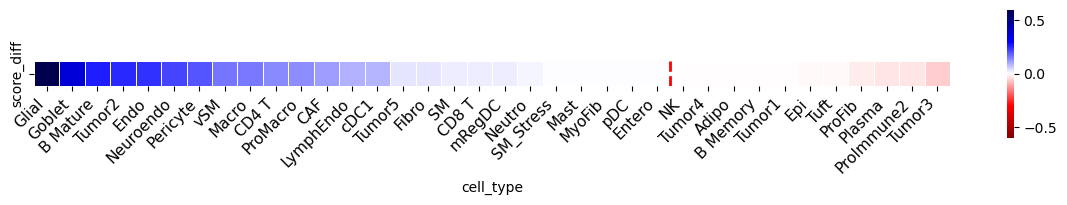

In [ ]:
# Leiden measures - heatmap

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


merged = pd.merge(
    summary_df_stlens,
    summary_df_kneed,
    on='cell_type',
    suffixes=('_stlens', '_kneed')
    )

# Calculate correlation difference
merged['score_diff'] = merged['best_jaccard_stlens'] - merged['best_jaccard_kneed']

# Sort by score difference
merged = merged.sort_values(by='score_diff', ascending=False).reset_index(drop=True)

# Prepare data for heatmap
heatmap_data = merged[['cell_type', 'score_diff']].set_index('cell_type').T

# Plot heatmap
plt.figure(figsize=(12, 2))

ax = sns.heatmap(
    heatmap_data,
    cmap='seismic_r',
    center=0,
    vmin=-0.6,
    vmax=0.6,
    annot=False,
    fmt='.2f',
    linewidths=0.5
    )

cell_labels = heatmap_data.columns

ax.set_xticks(np.arange(len(cell_labels)) + 0.5)

ax.set_xticklabels(cell_labels, rotation=45, ha='right', fontsize=11)

ax.set_aspect(aspect=1)

# red line
corrs = list(merged['score_diff'])

for i in range(len(corrs)-1):
    if corrs[i] * corrs[i+1] < 0:
        plt.axvline(x=i+1, color='red', linestyle='--', linewidth=2)
        break
plt.tight_layout()
plt.savefig('./stLENS/output/kneed_heatmap_visium.pdf', dpi=300)
plt.show()

# Jackstraw

## STOmics

In [ ]:
import numpy as np
import pandas as pd
import scanpy as sc
import anndata
anndata.settings.allow_write_nullable_strings = True

import rpy2.robjects as ro
from rpy2.robjects import numpy2ri
from rpy2.robjects.conversion import localconverter
from rpy2.robjects.packages import importr
from scipy.sparse import issparse

import warnings
warnings.filterwarnings('ignore')

# ── 로깅 시작 (선택) ──
import sys
sys.path.insert(0, './stLENS/logger')
from logger_utils import start_logger, stop_logger
proc = start_logger('seurat_jackstraw', interval=60)

[logger] started PID=882712  tracking PID=882530+children  interval=60s
[logger] output   → /bce/groups/pnucolab/analysis/stLENS/logger/seurat_jackstraw.json


In [ ]:
adata_js = sc.read_h5ad(
    './scLENS/scLENS_paper_yh/data/stomics/'
    'E16.5_E1S3_cell_bin_whole_brain.h5ad'
)

adata_js.X = adata_js.layers['counts'].copy()

sc.pp.filter_cells(adata_js, min_genes=200)
sc.pp.filter_genes(adata_js, min_cells=15)

In [ ]:
counts = adata_js.layers['counts']
if issparse(counts):
    counts_np = counts.toarray()
else:
    counts_np = np.asarray(counts)

counts_gc = counts_np.T.astype(np.float64) 

gene_names = list(adata_js.var_names)
cell_names = list(adata_js.obs_names)

In [ ]:
Seurat = importr('Seurat')

with localconverter(ro.default_converter + numpy2ri.converter):
    ro.globalenv['counts_r'] = ro.conversion.py2rpy(counts_gc)
ro.globalenv['gene_names'] = ro.StrVector(gene_names)
ro.globalenv['cell_names'] = ro.StrVector(cell_names)

In [ ]:
print('\n=== Seurat 파이프라인 시작 ===')

ro.r('''
rownames(counts_r) <- gene_names
colnames(counts_r) <- cell_names

library(Seurat)
set.seed(42)

cat("⑤ CreateSeuratObject...\n")
so <- CreateSeuratObject(counts = counts_r, project = "jackstraw_brain")
cat(sprintf(" created: %d features × %d cells\n", nrow(so), ncol(so)))

cat("⑥ NormalizeData...\n")
so <- NormalizeData(so, verbose = FALSE)

cat("⑦ FindVariableFeatures...\n")
so <- FindVariableFeatures(so, nfeatures = 2000, verbose = FALSE)

cat("⑧ ScaleData...\n")
so <- ScaleData(so, verbose = FALSE)

cat("⑨ RunPCA (npcs=100)...\n")
so <- RunPCA(so, npcs = 100, verbose = FALSE)

cat("⑩ JackStraw (num.replicate=10, dims=100, prop.freq=0.05)...\n")
so <- JackStraw(
    so,
    num.replicate = 10,
    dims          = 100,
    prop.freq     = 0.05,
    verbose       = TRUE
)

cat("⑪ ScoreJackStraw...\n")
so <- ScoreJackStraw(so, dims = 1:100)

cat("=== completed ===\n")
''')



=== Seurat 파이프라인 시작 ===
⑤ CreateSeuratObject...


R callback write-console: Warning:  


R callback write-console:  Data is of class matrix. Coercing to dgCMatrix.
  


 created: 19182 features × 65303 cells


⑥ NormalizeData...


...

99% ~00s          

 |++++++++++++++++++++++++++++++++++++++++++++++++++|

100% elapsed=02s  

⑪ ScoreJackStraw...


=== completed ===


In [ ]:
p_vals_df = ro.r('as.data.frame(so@reductions$pca@jackstraw$overall.p.values)')
with localconverter(ro.default_converter + numpy2ri.converter):
    p_vals_arr = np.asarray(ro.r('as.matrix(so@reductions$pca@jackstraw$overall.p.values)'))

pc_idx = p_vals_arr[:, 0].astype(int)
p_vals = p_vals_arr[:, 1]

In [ ]:
ro.r('''
library(ggplot2)

pdf("jackstrawplot_v2.pdf", width = 14, height = 8)
p <- JackStrawPlot(so, dims = 1:100)
print(p)
dev.off()
cat("save JackStrawPlot: jackstrawplot_v2.pdf\n")

pdf("elbowplot_v2.pdf", width = 10, height = 6)
p <- ElbowPlot(so, ndims = 100)
print(p)
dev.off()
cat("save ElbowPlot: elbowplot_v2.pdf\n")
''')

save JackStrawPlot: jackstrawplot_v2.pdf


save ElbowPlot: elbowplot_v2.pdf


R callback write-console: In addition:   


R callback write-console: Warning message:
  


R callback write-console: Removed 176703 rows containing missing values or values outside the scale range
(`geom_point()`). 
  


In [ ]:
import os
save_path = './stLENS/dataset/paper/stomics/jackstraw.h5ad'
os.makedirs(os.path.dirname(save_path), exist_ok=True)
adata_js.write_h5ad(save_path)

In [ ]:
import scanpy as sc
adata_js = sc.read_h5ad('./stLENS/dataset/paper/PCA_method/sejs_adata.h5ad')
adata_js

AnnData object with n_obs × n_vars = 65303 × 19182
    obs: 'Slice', 'region', 'sim anno', 'n_genes_by_counts', 'total_counts', 'annotation', 'n_genes'
    var: 'Gene', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'jackstraw', 'sim anno_colors'
    obsm: 'spatial'
    layers: 'counts'

In [ ]:
sc.pp.normalize_total(adata_js)
sc.pp.log1p(adata_js)

In [ ]:
n_signif = 12
sc.tl.pca(adata_js, n_comps=n_signif)

In [ ]:
sc.pp.neighbors(adata_js, n_pcs=n_signif) 
sc.tl.umap(adata_js)

/home/khyeonmin/micromamba/envs/stLENS/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
import numpy as np
def leiden_loop(adata):
    res_range = np.arange(0.5, 5.1, 0.5)
    for res in res_range:
        leiden_key = f"leiden_{res:.1f}"
        if leiden_key not in adata.obs:
            sc.tl.leiden(adata, resolution=res, key_added=leiden_key)

leiden_loop(adata_js)


/tmp/ipykernel_887877/20851495.py:7: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=res, key_added=leiden_key)


In [ ]:
adata_js.write_h5ad('./stLENS/dataset/paper/PCA_method/jack_leiden_loop.h5ad')

In [ ]:
from sklearn.metrics import jaccard_score
import pandas as pd
from tqdm import tqdm

def optimize_resolution_for_all_celltypes_jaccard(
    adata,
    average,
    annotation_key='annotation',
    res_range=np.arange(0.5, 5.1, 0.5)
):
    summary = []
    cell_types = adata.obs[annotation_key].cat.categories

    for cell_type in tqdm(cell_types, desc="Processing cell types"):
        jaccard_scores = []
        best_clusters = []
        resolutions_checked = []

        gt_mask = adata.obs[annotation_key] == cell_type
        if gt_mask.sum() == 0:
            continue

        for res in res_range:
            leiden_key = f"leiden_{res:.1f}"
            if leiden_key not in adata.obs.columns:
                continue
            
            cluster_names = adata.obs[leiden_key].cat.categories
            best_jaccard = -1
            best_cluster = None

            for cluster in cluster_names:
                pred_mask = adata.obs[leiden_key] == cluster

                _, score = jaccard_score(gt_mask, pred_mask, average=average)
                if score > best_jaccard:
                    best_jaccard = score
                    best_cluster = cluster

            jaccard_scores.append(best_jaccard)
            best_clusters.append(best_cluster)
            resolutions_checked.append(res)

        df = pd.DataFrame({
            'resolution': resolutions_checked,
            'jaccard': jaccard_scores,
            'best_cluster': best_clusters
        })

        best_idx = df['jaccard'].idxmax()
        best_row = df.loc[best_idx]
        summary.append({
            'cell_type': cell_type,
            'best_resolution': best_row['resolution'],
            'best_cluster': best_row['best_cluster'],
            'best_jaccard': best_row['jaccard']
        })

    return pd.DataFrame(summary)


In [ ]:
adata_js = adata_js[adata_js.obs['annotation'] != 'Unknown'].copy()

In [ ]:
name_map = {
    'Cajal-Retzius cell': 'Cajal',
    'Cerebellar granule neuroblasts': 'Cerebellar GN',
    'Choroid plexus': 'Choroid',
    'Cortical glutamatergic neuron': 'Ctx Glu neuron',
    'Cortical intermediate progenitor': 'Ctx IP',
    'Cortical or hippocampal glutamatergic neuron': 'Ctx/Hip Glu neuron',
    'Cranium fibroblast': 'Cranium FB',
    'Diencephalon glutamatergic neuron': 'Dience Glu neuron',
    'Dopaminergic neuron': 'DA neuron',
    'Dorsal hindbrain radial glia': 'Dorsal HB RG',
    'Endothelial cell': 'Endo',
    'Epidermis': 'Epid',
    'Erythrocyte': 'RBC',
    'Fibroblast': 'FB',
    'Forebrain GABAergic neuroblast': 'FB GABA NB',
    'Forebrain GABAergic neuron': 'FB GABA neuron',
    'Forebrain glutamatergic neuroblast': 'FB Glu NB',
    'Forebrain neuroblast': 'FB NB',
    'Forebrain radial glia': 'FB RG',
    'Hindbrain glioblast': 'HB GB',
    'Hindbrain glutamatergic neuroblast': 'HB Glu NB',
    'Hindbrain glutamatergic neuron': 'HB Glu neuron',
    'Hindbrain neuroblast': 'HB NB',
    'Hypothalamus neuron': 'Hypo neuron',
    'Midbrain glutamatergic neuroblast': 'MB Glu NB',
    'Midbrain glutamatergic neuron': 'MB Glu neuron',
    'Midbrain radial glia': 'MB RG',
    'Mixed region GABAergic neuron': 'Mixed GABA neuron',
    'Mixed region glioblast': 'Mixed GB',
    'Mixed region neuron': 'Mixed neuron',
    'Motor neuron': 'Motor neuron',
    'Olfactory neuron': 'Olf neuron',
    'Ventromedial hypothalamus GABAergic neuron': 'VMH GABA neuron'
}

In [ ]:
adata_js.obs['Chen et al.'] = adata_js.obs['annotation'].cat.rename_categories(name_map)

In [ ]:
summary_df_jack_st = optimize_resolution_for_all_celltypes_jaccard(
    adata_js,
    annotation_key='Chen et al.',
    average=None
)

Processing cell types: 100%|██████████| 33/33 [04:35<00:00,  8.36s/it]


In [ ]:
adata_js.write_h5ad('./stLENS/dataset/paper/PCA_method/jack_adata.h5ad')
summary_df_jack_st.to_csv('./stLENS/dataset/paper/PCA_method/summary_df_jack.csv')

In [ ]:
summary_df_stlens_st = pd.read_csv('./scLENS/output/stomics/summary_df_stlens.csv')

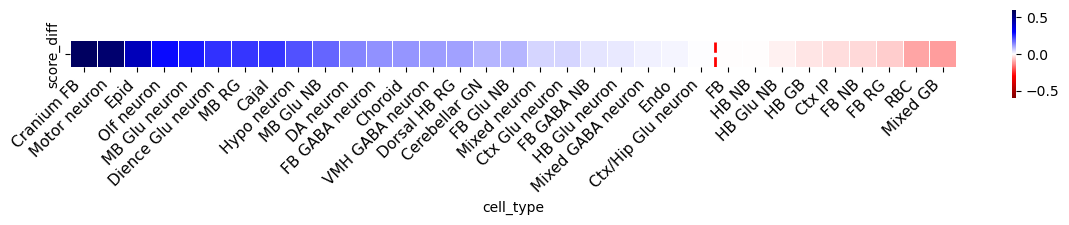

In [ ]:
# Leiden measures - heatmap

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


merged_st = pd.merge(
    summary_df_stlens_st,
    summary_df_jack_st,
    on='cell_type',
    suffixes=('_stlens', '_jack')
    )

# Calculate correlation difference
merged_st['score_diff'] = merged_st['best_jaccard_stlens'] - merged_st['best_jaccard_jack']

# Sort by score difference
merged_st = merged_st.sort_values(by='score_diff', ascending=False).reset_index(drop=True)

# Prepare data for heatmap
heatmap_data = merged_st[['cell_type', 'score_diff']].set_index('cell_type').T

# Plot heatmap
plt.figure(figsize=(12, 2))

ax = sns.heatmap(
    heatmap_data,
    cmap='seismic_r',
    center=0,
    vmin=-0.6,
    vmax=0.6,
    annot=False,
    fmt='.2f',
    linewidths=0.5
    )

cell_labels = heatmap_data.columns

ax.set_xticks(np.arange(len(cell_labels)) + 0.5)

ax.set_xticklabels(cell_labels, rotation=45, ha='right', fontsize=11)

ax.set_aspect(aspect=1)

# red line
corrs = list(merged_st['score_diff'])

for i in range(len(corrs)-1):
    if corrs[i] * corrs[i+1] < 0:
        plt.axvline(x=i+1, color='red', linestyle='--', linewidth=2)
        break
plt.tight_layout()
plt.savefig('./stLENS/dataset/paper/PCA_method/jack_heatmap_stomics.pdf', dpi=300)
plt.show()

## VisiumHD

In [ ]:
adata_js = sc.read_h5ad(
    './scLENS/scLENS_paper_yh/data/visiumhd/'
    'anndata_human_crc.h5ad'
)

# visiumHD: var_names duplicates -> deduplicate
adata_js.var_names_make_unique()

# visiumHD: .X is already raw counts (float32 integer values), no layers['counts'] available
# Backup to layers so downstream code that expects layers['counts'] still works
adata_js.layers['counts'] = adata_js.X.copy()

# QC filter
sc.pp.filter_cells(adata_js, min_genes=200)
sc.pp.filter_genes(adata_js, min_cells=15)

In [ ]:
counts = adata_js.layers['counts']
if issparse(counts):
    counts_np = counts.toarray()
else:
    counts_np = np.asarray(counts)

counts_gc = counts_np.T.astype(np.float64) 

gene_names = list(adata_js.var_names)
cell_names = list(adata_js.obs_names)

In [ ]:
Seurat = importr('Seurat')

with localconverter(ro.default_converter + numpy2ri.converter):
    ro.globalenv['counts_r'] = ro.conversion.py2rpy(counts_gc)
ro.globalenv['gene_names'] = ro.StrVector(gene_names)
ro.globalenv['cell_names'] = ro.StrVector(cell_names)

In [ ]:
print('\n=== Seurat pipeline start ===')

ro.r('''
rownames(counts_r) <- gene_names
colnames(counts_r) <- cell_names

library(Seurat)
set.seed(42)

cat("CreateSeuratObject...\n")
so <- CreateSeuratObject(counts = counts_r, project = "jackstraw_visiumhd")
cat(sprintf(" created: %d features x %d cells\n", nrow(so), ncol(so)))

cat("NormalizeData...\n")
so <- NormalizeData(so, verbose = FALSE)

cat("FindVariableFeatures...\n")
so <- FindVariableFeatures(so, nfeatures = 2000, verbose = FALSE)

cat("ScaleData...\n")
so <- ScaleData(so, verbose = FALSE)

cat("RunPCA (npcs=100)...\n")
so <- RunPCA(so, npcs = 100, verbose = FALSE)

cat("JackStraw (num.replicate=10, dims=100, prop.freq=0.05)...\n")
so <- JackStraw(
    so,
    num.replicate = 10,
    dims          = 100,
    prop.freq     = 0.05,
    verbose       = TRUE
)

cat("ScoreJackStraw...\n")
so <- ScoreJackStraw(so, dims = 1:100)

cat("=== completed ===\n")
''')



=== Seurat pipeline start ===
CreateSeuratObject...


R callback write-console: Warning:  


R callback write-console:  Data is of class matrix. Coercing to dgCMatrix.
  


 created: 16798 features x 159526 cells


NormalizeData...


...

99% ~00s          

 |++++++++++++++++++++++++++++++++++++++++++++++++++|

100% elapsed=02s  

ScoreJackStraw...


=== completed ===


In [ ]:
ro.r('''
library(ggplot2)

pdf("./stLENS/dataset/paper/PCA_method/jackstrawplot_vi.pdf", width = 14, height = 8)
p <- JackStrawPlot(so, dims = 1:100)
print(p)
dev.off()
cat("saved: jackstrawplot_vi.pdf\n")

pdf("./stLENS/dataset/paper/PCA_method/elbowplot_vi.pdf", width = 10, height = 6)
p <- ElbowPlot(so, ndims = 100)
print(p)
dev.off()
cat("saved: elbowplot_vi.pdf\n")
''')

saved: jackstrawplot_vi.pdf


saved: elbowplot_vi.pdf


R callback write-console: In addition:   


R callback write-console: Warning message:
  


R callback write-console: Removed 175434 rows containing missing values or values outside the scale range
(`geom_point()`). 
  


In [ ]:
import os
save_path = './stLENS/dataset/paper/PCA_method/sejs_vi_adata.h5ad'
os.makedirs(os.path.dirname(save_path), exist_ok=True)
adata_js.write_h5ad(save_path)
print(f'saved: {save_path}')

saved: /bce/groups/pnucolab/analysis/stLENS/dataset/paper/PCA_method/sejs_vi_adata.h5ad


In [ ]:
import scanpy as sc
adata_js = sc.read_h5ad('./stLENS/dataset/paper/PCA_method/sejs_vi_adata.h5ad')
adata_js

AnnData object with n_obs × n_vars = 159526 × 16798
    obs: 'in_tissue', 'array_row', 'array_col', 'location_id', 'region', 'DeconvolutionClass', 'DeconvolutionLabel1', 'DeconvolutionLabel2', 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'jackstraw', 'spatialdata_attrs'
    obsm: 'spatial'
    layers: 'counts'

In [ ]:
sc.pp.normalize_total(adata_js)
sc.pp.log1p(adata_js)

In [ ]:
n_signif = 20
print(f'using n_signif: {n_signif}')
sc.tl.pca(adata_js, n_comps=n_signif)

using n_signif: 20


In [ ]:
sc.pp.neighbors(adata_js, n_pcs=n_signif)
sc.tl.umap(adata_js)

In [ ]:
import numpy as np
def leiden_loop(adata):
    res_range = np.arange(0.5, 5.1, 0.5)
    for res in res_range:
        leiden_key = f"leiden_{res:.1f}"
        if leiden_key not in adata.obs:
            sc.tl.leiden(adata, resolution=res, key_added=leiden_key)

leiden_loop(adata_js)

/tmp/ipykernel_293158/3652331544.py:7: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=res, key_added=leiden_key)


/tmp/ipykernel_293158/3652331544.py:7: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=res, key_added=leiden_key)


/tmp/ipykernel_293158/3652331544.py:7: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=res, key_added=leiden_key)


/tmp/ipykernel_293158/3652331544.py:7: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=res, key_added=leiden_key)


/tmp/ipykernel_293158/3652331544.py:7: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=res, key_added=leiden_key)


/tmp/ipykernel_293158/3652331544.py:7: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=res, key_added=leiden_key)


/tmp/ipykernel_293158/3652331544.py:7: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=res, key_added=leiden_key)


/tmp/ipykernel_293158/3652331544.py:7: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=res, key_added=leiden_key)


/tmp/ipykernel_293158/3652331544.py:7: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=res, key_added=leiden_key)


/tmp/ipykernel_293158/3652331544.py:7: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=res, key_added=leiden_key)


In [ ]:
import anndata
anndata.settings.allow_write_nullable_strings = True

In [ ]:
adata_js.write_h5ad('./stLENS/dataset/paper/PCA_method/jack_leiden_loop_vi.h5ad')

In [ ]:
from sklearn.metrics import jaccard_score
import pandas as pd
from tqdm import tqdm

def optimize_resolution_for_all_celltypes_jaccard(
    adata,
    average,
    annotation_key='annotation',
    res_range=np.arange(0.5, 5.1, 0.5)
):
    summary = []
    cell_types = adata.obs[annotation_key].cat.categories

    for cell_type in tqdm(cell_types, desc="Processing cell types"):
        jaccard_scores = []
        best_clusters = []
        resolutions_checked = []

        gt_mask = adata.obs[annotation_key] == cell_type
        if gt_mask.sum() == 0:
            continue

        for res in res_range:
            leiden_key = f"leiden_{res:.1f}"
            if leiden_key not in adata.obs.columns:
                continue

            cluster_names = adata.obs[leiden_key].cat.categories
            best_jaccard = -1
            best_cluster = None

            for cluster in cluster_names:
                pred_mask = adata.obs[leiden_key] == cluster

                _, score = jaccard_score(gt_mask, pred_mask, average=average)
                if score > best_jaccard:
                    best_jaccard = score
                    best_cluster = cluster

            jaccard_scores.append(best_jaccard)
            best_clusters.append(best_cluster)
            resolutions_checked.append(res)

        df = pd.DataFrame({
            'resolution': resolutions_checked,
            'jaccard': jaccard_scores,
            'best_cluster': best_clusters
        })

        best_idx = df['jaccard'].idxmax()
        best_row = df.loc[best_idx]
        summary.append({
            'cell_type': cell_type,
            'best_resolution': best_row['resolution'],
            'best_cluster': best_row['best_cluster'],
            'best_jaccard': best_row['jaccard']
        })

    return pd.DataFrame(summary)

In [ ]:
name_map = {
    'Goblet': 'Goblet',
    'Tumor II': 'Tumor2',
    'CD4 T cell': 'CD4 T',
    'CAF': 'CAF',
    'Macrophage': 'Macro',
    'Proliferating Fibroblast': 'ProFib',
    'Tumor III': 'Tumor3',
    'Mature B': 'B Mature',
    'Pericytes': 'Pericyte',
    'Myofibroblast': 'MyoFib',
    'Endothelial': 'Endo',
    'CD8 T cell': 'CD8 T',
    'Tuft': 'Tuft',
    'Proliferating Macrophages': 'ProMacro',
    'Enterocyte': 'Entero',
    'Fibroblast': 'Fibro',
    'cDC I': 'cDC1',
    'mRegDC': 'mRegDC',
    'Plasma': 'Plasma',
    'Enteric Glial': 'Glial',
    'Tumor V': 'Tumor5',
    'Proliferating Immune II': 'ProImmune2',
    'Neutrophil': 'Neutro',
    'Tumor IV': 'Tumor4',
    'Neuroendocrine': 'Neuroendo',
    'Lymphatic Endothelial': 'LymphEndo',
    'Mast': 'Mast',
    'pDC': 'pDC',
    'Tumor I': 'Tumor1',
    'Epithelial': 'Epi',
    'vSM': 'vSM',
    'Smooth Muscle': 'SM',
    'Memory B': 'B Memory',
    'Adipocyte': 'Adipo',
    'SM Stress Response': 'SM_Stress',
    'NK': 'NK'
}

In [ ]:
adata_js.obs['Faria de Oliveira et al.'] = adata_js.obs['DeconvolutionLabel1'].cat.rename_categories(name_map)

In [ ]:
summary_df_jack_st = optimize_resolution_for_all_celltypes_jaccard(
    adata_js,
    annotation_key='Faria de Oliveira et al.',
    average=None
)


Processing cell types:   0%|          | 0/37 [00:00<?, ?it/s]


Processing cell types:   3%|▎         | 1/37 [00:23<13:50, 23.06s/it]


Processing cell types:   5%|▌         | 2/37 [00:46<13:36, 23.33s/it]


Processing cell types:   8%|▊         | 3/37 [01:09<13:06, 23.14s/it]


Processing cell types:  11%|█         | 4/37 [01:32<12:40, 23.04s/it]

...


Processing cell types:  92%|█████████▏| 34/37 [13:00<01:08, 22.83s/it]


Processing cell types:  95%|█████████▍| 35/37 [13:23<00:45, 22.74s/it]


Processing cell types:  97%|█████████▋| 36/37 [13:45<00:22, 22.63s/it]


Processing cell types: 100%|██████████| 37/37 [14:07<00:00, 22.53s/it]


Processing cell types: 100%|██████████| 37/37 [14:07<00:00, 22.91s/it]

In [ ]:
adata_js.write_h5ad('./stLENS/dataset/paper/PCA_method/jack_vi_adata.h5ad')
summary_df_jack_st.to_csv('./stLENS/dataset/paper/PCA_method/summary_df_jack_vi.csv')

In [ ]:
summary_df_stlens_st = pd.read_csv('./scLENS/output/visiumhd/summary_df_stlens.csv')

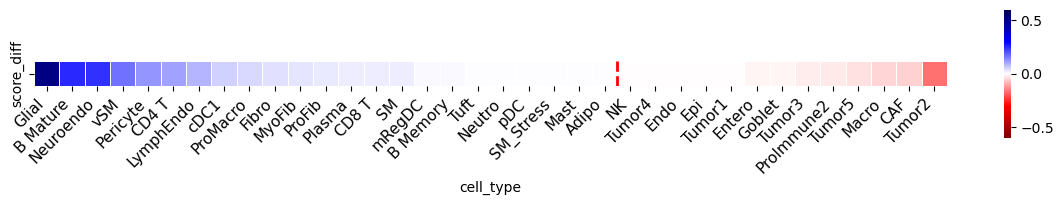

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

merged_st = pd.merge(
    summary_df_stlens_st,
    summary_df_jack_st,
    on='cell_type',
    suffixes=('_stlens', '_jack')
)

merged_st['score_diff'] = merged_st['best_jaccard_stlens'] - merged_st['best_jaccard_jack']
merged_st = merged_st.sort_values(by='score_diff', ascending=False).reset_index(drop=True)

heatmap_data = merged_st[['cell_type', 'score_diff']].set_index('cell_type').T

plt.figure(figsize=(12, 2))
ax = sns.heatmap(
    heatmap_data,
    cmap='seismic_r',
    center=0,
    vmin=-0.6,
    vmax=0.6,
    annot=False,
    fmt='.2f',
    linewidths=0.5
)

cell_labels = heatmap_data.columns
ax.set_xticks(np.arange(len(cell_labels)) + 0.5)
ax.set_xticklabels(cell_labels, rotation=45, ha='right', fontsize=11)
ax.set_aspect(aspect=1)

corrs = list(merged_st['score_diff'])
for i in range(len(corrs)-1):
    if corrs[i] * corrs[i+1] < 0:
        plt.axvline(x=i+1, color='red', linestyle='--', linewidth=2)
        break
plt.tight_layout()
plt.savefig('./stLENS/dataset/paper/PCA_method/jack_heatmap_visium.pdf', dpi=300)
plt.show()

# 95% variance

## STOmics

In [ ]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import scanpy as sc

In [ ]:
adata_sl = sc.read_h5ad('./scLENS/scLENS_paper_yh/data/stomics/E16.5_E1S3_cell_bin_whole_brain.h5ad')

In [ ]:
sc.pp.filter_cells(adata_sl, min_genes=200)
sc.pp.filter_genes(adata_sl, min_cells=15)
adata_sl

AnnData object with n_obs × n_vars = 65303 × 19182
    obs: 'Slice', 'region', 'sim anno', 'n_genes_by_counts', 'total_counts', 'annotation', 'n_genes'
    var: 'Gene', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'sim anno_colors'
    obsm: 'spatial'
    layers: 'counts'

In [ ]:
adata_sl.X = adata_sl.layers['counts'].copy()

In [ ]:
sc.pp.normalize_total(adata_sl)
sc.pp.log1p(adata_sl)

In [ ]:
X = adata_sl.X.toarray()

In [ ]:
pca = PCA(n_components=0.95, svd_solver='full')
scores = pca.fit_transform(X)
print(pca.n_components_)

8814


In [ ]:
optimal_pc = pca.n_components_

In [ ]:
adata_sl.obsm['X_pca']    = scores                     
adata_sl.varm['PCs']      = pca.components_.T          
adata_sl.uns['pca']       = {
    'variance'        : pca.explained_variance_,
    'variance_ratio'  : pca.explained_variance_ratio_,
}

In [ ]:
sc.pp.neighbors(adata_sl, n_pcs=optimal_pc)
sc.tl.umap(adata_sl)

/bce/groups/pnucolab/analysis/stLENS/.bipca/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Leiden Clustering across resolutions
def leiden_loop(adata):
    res_range=np.arange(0.5, 5.1, 0.5)
    for res in res_range:
        leiden_key = f"leiden_{res:.1f}"
        if leiden_key not in adata.obs:
            sc.tl.leiden(adata, resolution=res, key_added=leiden_key)

In [ ]:
leiden_loop(adata_sl)

/tmp/ipykernel_2445103/2986899218.py:7: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=res, key_added=leiden_key)


In [ ]:
adata_sl.write_h5ad('./stLENS/dataset/paper/PCA_method/scikit_leiden_loop.h5ad')

In [ ]:
from sklearn.metrics import jaccard_score
import pandas as pd
from tqdm import tqdm

def optimize_resolution_for_all_celltypes_jaccard(
    adata,
    average,
    annotation_key='annotation',
    res_range=np.arange(0.5, 5.1, 0.5)
):
    summary = []
    cell_types = adata.obs[annotation_key].cat.categories

    for cell_type in tqdm(cell_types, desc="Processing cell types"):
        jaccard_scores = []
        best_clusters = []
        resolutions_checked = []

        gt_mask = adata.obs[annotation_key] == cell_type
        if gt_mask.sum() == 0:
            continue

        for res in res_range:
            leiden_key = f"leiden_{res:.1f}"
            if leiden_key not in adata.obs.columns:
                continue
            
            cluster_names = adata.obs[leiden_key].cat.categories
            best_jaccard = -1
            best_cluster = None

            for cluster in cluster_names:
                pred_mask = adata.obs[leiden_key] == cluster

                _, score = jaccard_score(gt_mask, pred_mask, average=average)
                if score > best_jaccard:
                    best_jaccard = score
                    best_cluster = cluster

            jaccard_scores.append(best_jaccard)
            best_clusters.append(best_cluster)
            resolutions_checked.append(res)

        df = pd.DataFrame({
            'resolution': resolutions_checked,
            'jaccard': jaccard_scores,
            'best_cluster': best_clusters
        })

        best_idx = df['jaccard'].idxmax()
        best_row = df.loc[best_idx]
        summary.append({
            'cell_type': cell_type,
            'best_resolution': best_row['resolution'],
            'best_cluster': best_row['best_cluster'],
            'best_jaccard': best_row['jaccard']
        })

    return pd.DataFrame(summary)


In [ ]:
adata_sl = adata_sl[adata_sl.obs['annotation'] != 'Unknown'].copy()

In [ ]:
name_map = {
    'Cajal-Retzius cell': 'Cajal',
    'Cerebellar granule neuroblasts': 'Cerebellar GN',
    'Choroid plexus': 'Choroid',
    'Cortical glutamatergic neuron': 'Ctx Glu neuron',
    'Cortical intermediate progenitor': 'Ctx IP',
    'Cortical or hippocampal glutamatergic neuron': 'Ctx/Hip Glu neuron',
    'Cranium fibroblast': 'Cranium FB',
    'Diencephalon glutamatergic neuron': 'Dience Glu neuron',
    'Dopaminergic neuron': 'DA neuron',
    'Dorsal hindbrain radial glia': 'Dorsal HB RG',
    'Endothelial cell': 'Endo',
    'Epidermis': 'Epid',
    'Erythrocyte': 'RBC',
    'Fibroblast': 'FB',
    'Forebrain GABAergic neuroblast': 'FB GABA NB',
    'Forebrain GABAergic neuron': 'FB GABA neuron',
    'Forebrain glutamatergic neuroblast': 'FB Glu NB',
    'Forebrain neuroblast': 'FB NB',
    'Forebrain radial glia': 'FB RG',
    'Hindbrain glioblast': 'HB GB',
    'Hindbrain glutamatergic neuroblast': 'HB Glu NB',
    'Hindbrain glutamatergic neuron': 'HB Glu neuron',
    'Hindbrain neuroblast': 'HB NB',
    'Hypothalamus neuron': 'Hypo neuron',
    'Midbrain glutamatergic neuroblast': 'MB Glu NB',
    'Midbrain glutamatergic neuron': 'MB Glu neuron',
    'Midbrain radial glia': 'MB RG',
    'Mixed region GABAergic neuron': 'Mixed GABA neuron',
    'Mixed region glioblast': 'Mixed GB',
    'Mixed region neuron': 'Mixed neuron',
    'Motor neuron': 'Motor neuron',
    'Olfactory neuron': 'Olf neuron',
    'Ventromedial hypothalamus GABAergic neuron': 'VMH GABA neuron'
}

In [ ]:
adata_sl.obs['Chen et al.'] = adata_sl.obs['annotation'].cat.rename_categories(name_map)

In [ ]:
summary_df_sklearn_st = optimize_resolution_for_all_celltypes_jaccard(
    adata_sl,
    annotation_key='Chen et al.',
    average=None
)


Processing cell types:   0%|          | 0/33 [00:00<?, ?it/s]


Processing cell types:   3%|▎         | 1/33 [00:26<14:17, 26.81s/it]


Processing cell types:   6%|▌         | 2/33 [00:53<13:49, 26.76s/it]


Processing cell types:   9%|▉         | 3/33 [01:20<13:29, 26.97s/it]


Processing cell types:  12%|█▏        | 4/33 [01:47<13:02, 26.99s/it]

...


Processing cell types:  91%|█████████ | 30/33 [13:29<01:21, 27.29s/it]


Processing cell types:  94%|█████████▍| 31/33 [13:54<00:52, 26.42s/it]


Processing cell types:  97%|█████████▋| 32/33 [14:19<00:25, 25.92s/it]


Processing cell types: 100%|██████████| 33/33 [14:46<00:00, 26.29s/it]


Processing cell types: 100%|██████████| 33/33 [14:46<00:00, 26.85s/it]

In [ ]:
adata_sl.write_h5ad('./stLENS/dataset/paper/PCA_method/scikit_adata.h5ad')
summary_df_sklearn_st.to_csv('./stLENS/dataset/paper/PCA_method/summary_df_sklearn.csv')

In [ ]:
summary_df_stlens_st = pd.read_csv('./scLENS/output/stomics/summary_df_stlens.csv')

In [ ]:
stlens_adata_st = sc.read_h5ad('./scLENS/output/stomics/stlens_result.h5ad')

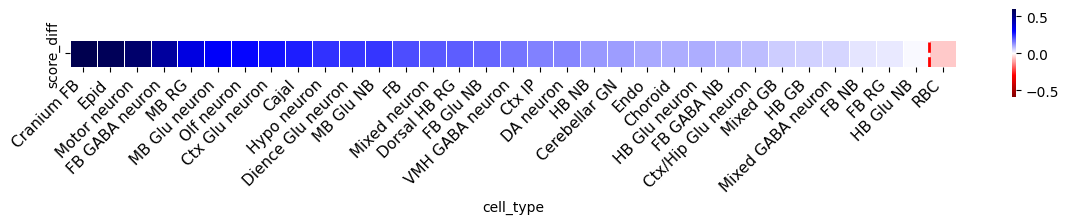

In [ ]:
# Leiden measures - heatmap

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


merged_st = pd.merge(
    summary_df_stlens_st,
    summary_df_sklearn_st,
    on='cell_type',
    suffixes=('_stlens', '_sklearn')
    )

# Calculate correlation difference
merged_st['score_diff'] = merged_st['best_jaccard_stlens'] - merged_st['best_jaccard_sklearn']

# Sort by score difference
merged_st = merged_st.sort_values(by='score_diff', ascending=False).reset_index(drop=True)

# Prepare data for heatmap
heatmap_data = merged_st[['cell_type', 'score_diff']].set_index('cell_type').T

# Plot heatmap
plt.figure(figsize=(12, 2))

ax = sns.heatmap(
    heatmap_data,
    cmap='seismic_r',
    center=0,
    vmin=-0.6,
    vmax=0.6,
    annot=False,
    fmt='.2f',
    linewidths=0.5
    )

cell_labels = heatmap_data.columns

ax.set_xticks(np.arange(len(cell_labels)) + 0.5)

ax.set_xticklabels(cell_labels, rotation=45, ha='right', fontsize=11)

ax.set_aspect(aspect=1)

# red line
corrs = list(merged_st['score_diff'])

for i in range(len(corrs)-1):
    if corrs[i] * corrs[i+1] < 0:
        plt.axvline(x=i+1, color='red', linestyle='--', linewidth=2)
        break
plt.tight_layout()
plt.savefig('./stLENS/dataset/paper/PCA_method/sklearn_heatmap_stomics.pdf', dpi=300)
plt.show()

## VisiumHD

In [ ]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import scanpy as sc
import anndata
anndata.settings.allow_write_nullable_strings = True

In [ ]:
adata_sl = sc.read_h5ad('./scLENS/scLENS_paper_yh/data/visiumhd/anndata_human_crc.h5ad')

/bce/groups/pnucolab/analysis/stLENS/.bipca/lib/python3.12/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [ ]:
sc.pp.filter_cells(adata_sl, min_genes=200)
sc.pp.filter_genes(adata_sl, min_cells=15)
adata_sl

AnnData object with n_obs × n_vars = 159526 × 16798
    obs: 'in_tissue', 'array_row', 'array_col', 'location_id', 'region', 'DeconvolutionClass', 'DeconvolutionLabel1', 'DeconvolutionLabel2', 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'

In [ ]:
sc.pp.normalize_total(adata_sl)
sc.pp.log1p(adata_sl)

In [ ]:
X = adata_sl.X.toarray()

In [ ]:
pca = PCA(n_components=0.95, svd_solver='full')
scores = pca.fit_transform(X)
print(pca.n_components_)

8824


In [ ]:
optimal_pc = pca.n_components_

In [ ]:
adata_sl.obsm['X_pca']    = scores                     
adata_sl.varm['PCs']      = pca.components_.T          
adata_sl.uns['pca']       = {
    'variance'        : pca.explained_variance_,
    'variance_ratio'  : pca.explained_variance_ratio_,
}

In [ ]:
sc.pp.neighbors(adata_sl, n_pcs=optimal_pc)
sc.tl.umap(adata_sl)

/bce/groups/pnucolab/analysis/stLENS/.bipca/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Leiden Clustering across resolutions
def leiden_loop(adata):
    res_range=np.arange(0.5, 5.1, 0.5)
    for res in res_range:
        leiden_key = f"leiden_{res:.1f}"
        if leiden_key not in adata.obs:
            sc.tl.leiden(adata, resolution=res, key_added=leiden_key)

In [ ]:
leiden_loop(adata_sl)

/tmp/ipykernel_3346824/2986899218.py:7: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=res, key_added=leiden_key)


In [ ]:
adata_sl.write_h5ad('./stLENS/dataset/paper/PCA_method/scikit_leiden_loop_vi.h5ad')

In [ ]:
from sklearn.metrics import jaccard_score
import pandas as pd
from tqdm import tqdm

def optimize_resolution_for_all_celltypes_jaccard(
    adata,
    average,
    annotation_key='annotation',
    res_range=np.arange(0.5, 5.1, 0.5)
):
    summary = []
    cell_types = adata.obs[annotation_key].cat.categories

    for cell_type in tqdm(cell_types, desc="Processing cell types"):
        jaccard_scores = []
        best_clusters = []
        resolutions_checked = []

        gt_mask = adata.obs[annotation_key] == cell_type
        if gt_mask.sum() == 0:
            continue

        for res in res_range:
            leiden_key = f"leiden_{res:.1f}"
            if leiden_key not in adata.obs.columns:
                continue
            
            cluster_names = adata.obs[leiden_key].cat.categories
            best_jaccard = -1
            best_cluster = None

            for cluster in cluster_names:
                pred_mask = adata.obs[leiden_key] == cluster

                _, score = jaccard_score(gt_mask, pred_mask, average=average)
                if score > best_jaccard:
                    best_jaccard = score
                    best_cluster = cluster

            jaccard_scores.append(best_jaccard)
            best_clusters.append(best_cluster)
            resolutions_checked.append(res)

        df = pd.DataFrame({
            'resolution': resolutions_checked,
            'jaccard': jaccard_scores,
            'best_cluster': best_clusters
        })

        best_idx = df['jaccard'].idxmax()
        best_row = df.loc[best_idx]
        summary.append({
            'cell_type': cell_type,
            'best_resolution': best_row['resolution'],
            'best_cluster': best_row['best_cluster'],
            'best_jaccard': best_row['jaccard']
        })

    return pd.DataFrame(summary)


In [ ]:
adata_sl = adata_sl[adata_sl.obs['DeconvolutionLabel1'] != 'Unknown'].copy()

In [ ]:
summary_df_stlens_st = pd.read_csv('./scLENS/output/visiumhd/summary_df_stlens.csv')

In [ ]:
stlens_adata_st = sc.read_h5ad('./scLENS/output/visiumhd/stlens_result.h5ad')

In [ ]:
name_map = {
    'Goblet': 'Goblet',
    'Tumor II': 'Tumor2',
    'CD4 T cell': 'CD4 T',
    'CAF': 'CAF',
    'Macrophage': 'Macro',
    'Proliferating Fibroblast': 'ProFib',
    'Tumor III': 'Tumor3',
    'Mature B': 'B Mature',
    'Pericytes': 'Pericyte',
    'Myofibroblast': 'MyoFib',
    'Endothelial': 'Endo',
    'CD8 T cell': 'CD8 T',
    'Tuft': 'Tuft',
    'Proliferating Macrophages': 'ProMacro',
    'Enterocyte': 'Entero',
    'Fibroblast': 'Fibro',
    'cDC I': 'cDC1',
    'mRegDC': 'mRegDC',
    'Plasma': 'Plasma',
    'Enteric Glial': 'Glial',
    'Tumor V': 'Tumor5',
    'Proliferating Immune II': 'ProImmune2',
    'Neutrophil': 'Neutro',
    'Tumor IV': 'Tumor4',
    'Neuroendocrine': 'Neuroendo',
    'Lymphatic Endothelial': 'LymphEndo',
    'Mast': 'Mast',
    'pDC': 'pDC',
    'Tumor I': 'Tumor1',
    'Epithelial': 'Epi',
    'vSM': 'vSM',
    'Smooth Muscle': 'SM',
    'Memory B': 'B Memory',
    'Adipocyte': 'Adipo',
    'SM Stress Response': 'SM_Stress',
    'NK': 'NK'
    }

In [ ]:
adata_sl.obs['Faria de Oliveira et al.'] = adata_sl.obs['DeconvolutionLabel1'].cat.rename_categories(name_map)

In [ ]:
summary_df_bipca_vi = optimize_resolution_for_all_celltypes_jaccard(
    adata_sl, 
    annotation_key = 'Faria de Oliveira et al.', 
    average = None)


Processing cell types:   0%|          | 0/37 [00:00<?, ?it/s]


Processing cell types:   3%|▎         | 1/37 [00:30<18:25, 30.71s/it]


Processing cell types:   5%|▌         | 2/37 [01:02<18:09, 31.13s/it]


Processing cell types:   8%|▊         | 3/37 [01:36<18:35, 32.82s/it]


Processing cell types:  11%|█         | 4/37 [02:07<17:38, 32.07s/it]

...


Processing cell types:  92%|█████████▏| 34/37 [21:09<02:05, 41.83s/it]


Processing cell types:  95%|█████████▍| 35/37 [21:45<01:19, 39.91s/it]


Processing cell types:  97%|█████████▋| 36/37 [22:20<00:38, 38.46s/it]


Processing cell types: 100%|██████████| 37/37 [23:02<00:00, 39.48s/it]


Processing cell types: 100%|██████████| 37/37 [23:02<00:00, 37.36s/it]

In [ ]:
adata_sl.write_h5ad('./stLENS/dataset/paper/PCA_method/scikit_vi_adata.h5ad')

In [ ]:
summary_df_bipca_vi.to_csv('./stLENS/dataset/paper/PCA_method/summary_df_scikit_vi.csv', )

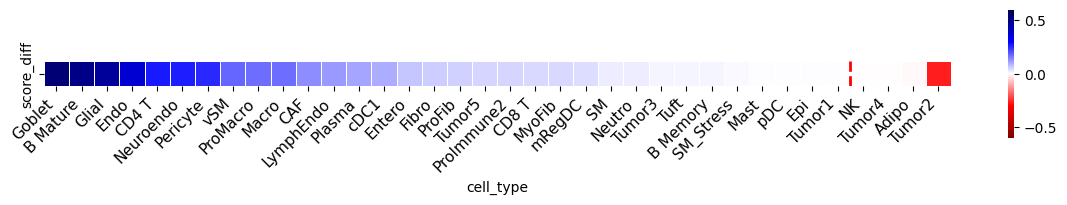

In [ ]:
# Leiden measures - heatmap

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


merged_st = pd.merge(
    summary_df_stlens_st,
    summary_df_bipca_vi,
    on='cell_type',
    suffixes=('_stlens', '_bipca')
    )

# Calculate correlation difference
merged_st['score_diff'] = merged_st['best_jaccard_stlens'] - merged_st['best_jaccard_bipca']

# Sort by score difference
merged_st = merged_st.sort_values(by='score_diff', ascending=False).reset_index(drop=True)

# Prepare data for heatmap
heatmap_data = merged_st[['cell_type', 'score_diff']].set_index('cell_type').T

# Plot heatmap
plt.figure(figsize=(12, 2))

ax = sns.heatmap(
    heatmap_data,
    cmap='seismic_r',
    center=0,
    vmin=-0.6,
    vmax=0.6,
    annot=False,
    fmt='.2f',
    linewidths=0.5
    )

cell_labels = heatmap_data.columns

ax.set_xticks(np.arange(len(cell_labels)) + 0.5)

ax.set_xticklabels(cell_labels, rotation=45, ha='right', fontsize=11)

ax.set_aspect(aspect=1)

# red line
corrs = list(merged_st['score_diff'])

for i in range(len(corrs)-1):
    if corrs[i] * corrs[i+1] < 0:
        plt.axvline(x=i+1, color='red', linestyle='--', linewidth=2)
        break
plt.tight_layout()
plt.savefig('./stLENS/dataset/paper/PCA_method/scikit_heatmap_visium.pdf', dpi=300)
plt.show()